In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
import numpy as np
import pandas as pd

n = 1000000

study = np.random.randint(2,10,n)
sleep = np.random.randint(4,9,n)
screen = np.random.randint(1,10,n)
attendance = np.random.randint(55,100,n)
stress = np.random.randint(1,11,n)
exercise = np.random.randint(0,2,n)


stress = stress + np.random.normal(0,1,n)
score = (
    0.33*stress +
    0.33*(10-study) +
    0.33*(100-attendance)/10
)

performance = np.where(
    score > 6, 2,
    np.where(score < 4, 0, 1)
)

df = pd.DataFrame({
    "study":study,
    "sleep":sleep,
    "screen":screen,
    "attendance":attendance,
    "stress":stress,
    "exercise":exercise,
    "performance":performance
})

X = df.drop("performance", axis=1)
y = df["performance"]



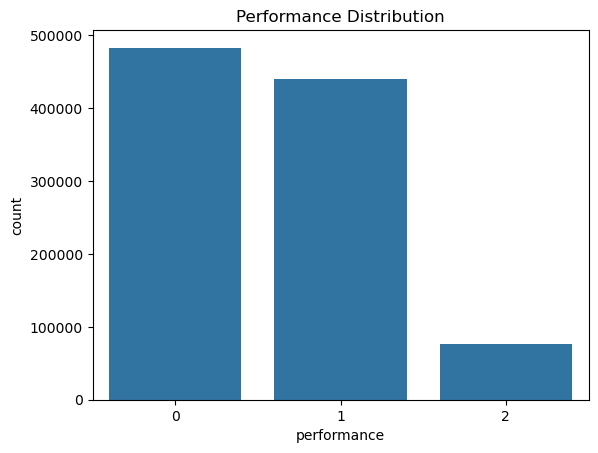

In [21]:
sns.countplot(x="performance", data=df)
plt.title("Performance Distribution")
plt.show()


In [22]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)  # learn scaling
X_test = scaler.transform(X_test)        # apply same scaling


model = LogisticRegression(max_iter=1000)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("accuracy:", accuracy_score(y_test, y_pred)*100, "%")
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

print(model.coef_)

accuracy: 99.9755 %
[[96543    17     0]
 [    5 88100     6]
 [    0    21 15308]]
[[ 4.28780353e+01 -1.95025955e-03  7.00944676e-03  2.43333520e+01
  -5.69529037e+01  4.97640706e-03]
 [-7.60802814e+00  1.36235048e-02 -4.47986203e-03 -4.30607161e+00
   1.01108602e+01 -3.79172050e-04]
 [-3.52700072e+01 -1.16732453e-02 -2.52958473e-03 -2.00272804e+01
   4.68420435e+01 -4.59723501e-03]]


In [23]:
#model download

import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))